Two Tailed Test
p-value: 0.5225602746220779
Fail to reject H0
Right Tailed Test p-value: 0.26128013731103894
Left Tailed Test p-value: 0.7387198626889611


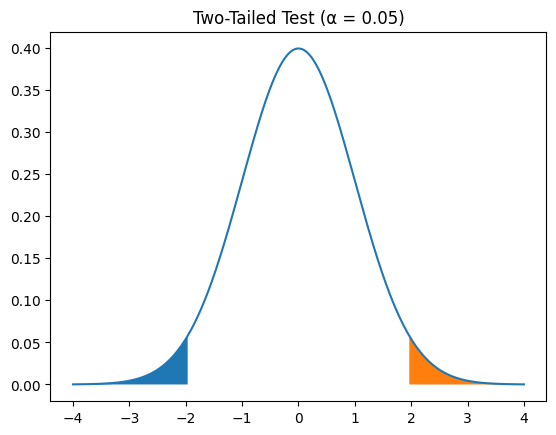

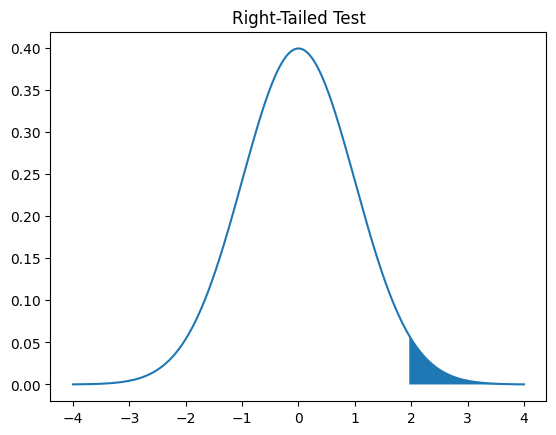

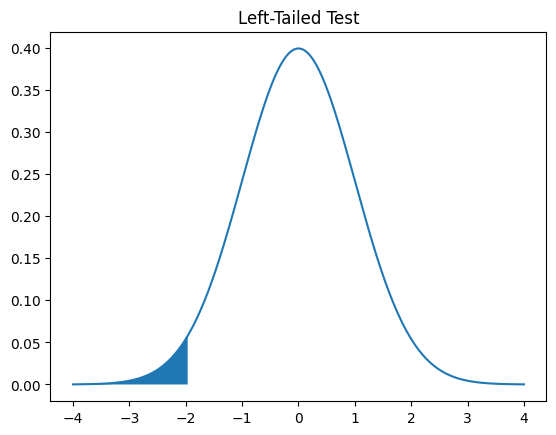

Saving Netflix.csv to Netflix (1).csv
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
T-stat: 178.72436637716777
P-value: 0.0
Reject H0 → Movies are longer
T-stat: 26.500573562871065
P-value: 1.342311985065777e-146
Reject H0 → Duration is different


Z-stat: 26.500573562871114
P-value: 0.0


Chi2: 1047.6941440561634
P-value: 6.822436324208583e-213
Reject H0 → Type & Rating related
F-stat: 594.0400128620067
P-value: 6.214545851106076e-228
Reject H0 → At least one country differs


In [12]:
import numpy as np
from scipy import stats
from scipy.stats import norm
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import pandas as pd

# ---------------- IRIS DATA ----------------
iris = load_iris()
data = iris.data[:, 0]  # sepal length

# Two Tailed Test
t_stat, p_value = stats.ttest_1samp(data, 5.8)
print("Two Tailed Test")
print("p-value:", p_value)
print("Reject H0" if p_value < 0.05 else "Fail to reject H0")

# Right Tailed Test
t_stat, p_value = stats.ttest_1samp(data, 5.8)
p_value = p_value/2 if t_stat > 0 else 1 - (p_value/2)
print("Right Tailed Test p-value:", p_value)

# Left Tailed Test
t_stat, p_value = stats.ttest_1samp(data, 5.8)
p_value = p_value/2 if t_stat < 0 else 1 - (p_value/2)
print("Left Tailed Test p-value:", p_value)

# ---------------- Z TEST VISUALIZATION ----------------
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.plot(x, y)
plt.fill_between(x, y, where=(x <= -1.96))
plt.fill_between(x, y, where=(x >= 1.96))
plt.title("Two-Tailed Test (α = 0.05)")
plt.show()

plt.plot(x, y)
plt.fill_between(x, y, where=(x >= 1.96))
plt.title("Right-Tailed Test")
plt.show()

plt.plot(x, y)
plt.fill_between(x, y, where=(x <= -1.96))
plt.title("Left-Tailed Test")
plt.show()

# ---------------- NETFLIX DATA ----------------
from google.colab import files

uploaded = files.upload()

# Automatically get correct filename (no naming errors)
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# Clean column names (important)
df.columns = df.columns.str.strip()

print(df.columns)   # always check once
df.head()

# ---------------- DATA FILTER ----------------
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

# Clean duration
movies_duration_clean = pd.to_numeric(
    movies['duration'].str.extract(r'(\d+)', expand=False),
    errors='coerce'
).dropna()

tv_shows_duration_clean = pd.to_numeric(
    tv_shows['duration'].str.extract(r'(\d+)', expand=False),
    errors='coerce'
).dropna()

# ---------------- T-TEST (2 SAMPLE) ----------------
t_stat, p_value = stats.ttest_ind(movies_duration_clean, tv_shows_duration_clean)

print("T-stat:", t_stat)
print("P-value:", p_value)
print("Reject H0 → Movies are longer" if p_value < 0.05 else "Fail to reject H0")


# ---------------- T-TEST (1 SAMPLE) ----------------
t_stat, p_value = stats.ttest_1samp(movies_duration_clean, 90)

print("T-stat:", t_stat)
print("P-value:", p_value)
print("Reject H0 → Duration is different" if p_value < 0.05 else "Fail to reject H0")
print()


# ---------------- Z-TEST ----------------
mean = np.mean(movies_duration_clean)
std = np.std(movies_duration_clean, ddof=1)
n = len(movies_duration_clean)

print()

z_stat = (mean - 90) / (std / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Z-stat:", z_stat)
print("P-value:", p_value)
print()


# ---------------- CHI-SQUARE ----------------
contingency = pd.crosstab(df['type'], df['rating'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print()


print("Chi2:", chi2)
print("P-value:", p)
print("Reject H0 → Type & Rating related" if p < 0.05 else "Independent")

# ---------------- ANOVA ----------------
usa = pd.to_numeric(
    df[df['country'] == 'United States']['duration'].str.extract(r'(\d+)', expand=False),
    errors='coerce'
).dropna()

india = pd.to_numeric(
    df[df['country'] == 'India']['duration'].str.extract(r'(\d+)', expand=False),
    errors='coerce'
).dropna()

uk = pd.to_numeric(
    df[df['country'] == 'United Kingdom']['duration'].str.extract(r'(\d+)', expand=False),
    errors='coerce'
).dropna()

f_stat, p_value = stats.f_oneway(usa, india, uk)

print("F-stat:", f_stat)
print("P-value:", p_value)
print("Reject H0 → At least one country differs" if p_value < 0.05 else "No significant difference")